In [ ]:
from langgraph.graph import START, END, StateGraph
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Optional
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import pandas as pd
import os
import re
import json
import ast
from get_coordinates import get_city_coordinates
from air_quality import (
    get_current_air_quality,
    get_forecast_air_quality,
    clean_air_quality_data, 
    plot_air_quality_data
)
load_dotenv()

True

In [2]:
model = ChatOllama(
    model="deepseek-r1:1.5b",
    temperature=0.6,
    reasoning=True
)

In [3]:
from langchain.prompts import PromptTemplate, FewShotPromptTemplate
from langchain.prompts.example_selector import SemanticSimilarityExampleSelector
from langchain.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

# -------------------------------
# Step 1. Parse Example
# -------------------------------
def escape_braces(s: str) -> str:
    return s.replace("{", "{{").replace("}", "}}")
    
# -------------------------------
# Step 1. Define your examples
# -------------------------------
examples = [
    {"query": "What is air quality in Delhi, India today?",
     "output": escape_braces('{"query_type": "current", "city_name": "Delhi", "country_code": "IN"}')},
    
    {"query": "Air quality of Pune, India for next 3 days",
     "output": escape_braces('{"query_type": "forecast", "city_name": "Pune", "country_code": "IN", "days": 3}')},
    
    {"query": "Show air quality in London UK now",
     "output": escape_braces('{"query_type": "current", "city_name": "London", "country_code": "GB"}')},
    
    {"query": "Forecast for Paris, France for 7 days",
     "output": escape_braces('{"query_type": "forecast", "city_name": "Paris", "country_code": "FR", "days": 7}')},
]

# -------------------------------
# Step 2. Set up embeddings + selector
# -------------------------------
embeddings = OllamaEmbeddings(model="mxbai-embed-large:latest")

example_selector = SemanticSimilarityExampleSelector.from_examples(
    examples=examples,
    embeddings=embeddings,
    vectorstore_cls=FAISS,
    k=3,
    input_keys=["query"]   # match user query
)

# -------------------------------
# Step 3. Define the example prompt format
# -------------------------------
example_prompt = PromptTemplate(
    query_variables=["query", "output"],
    template="User query: {query}\nOutput: {output}\n"
)

# -------------------------------
# Step 4. Build the few-shot prompt
# -------------------------------
few_shot_prompt = FewShotPromptTemplate(
    example_selector=example_selector,
    example_prompt=example_prompt,
    prefix="Extract structured air quality info as JSON with keys: query_type, city_name, country_code, days (if forecast).\n\n",
    suffix="User query: {query}\nOutput:",
    input_variables=["query"]
)

# -------------------------------
# Step 5. Try it with a query
# -------------------------------
user_query = "Forecast for Paris, France for 7 days"

formatted_prompt = few_shot_prompt.format(query=user_query)
print(formatted_prompt)

Extract structured air quality info as JSON with keys: query_type, city_name, country_code, days (if forecast).



User query: Forecast for Paris, France for 7 days
Output: {"query_type": "forecast", "city_name": "Paris", "country_code": "FR", "days": 7}


User query: Show air quality in London UK now
Output: {"query_type": "current", "city_name": "London", "country_code": "GB"}


User query: Air quality of Pune, India for next 3 days
Output: {"query_type": "forecast", "city_name": "Pune", "country_code": "IN", "days": 3}


User query: Forecast for Paris, France for 7 days
Output:


In [5]:
class AirQuerySchema(BaseModel):
    query_type: Literal["current", "forecast"] = Field(
        description="Pick one of the air_quality query_type: 'current' or 'forecast'"
    )
    city_name: str = Field(description="City Name")
    country_code: str = Field(description="Country Code in ISO-3166-1 alpha-2")
    days: Optional[int] = Field(
        7, description="This field is required when using forecast"
    )
    
def get_air_query_inputs(user_prompt: str, model, few_shot_prompt: FewShotPromptTemplate) -> Optional[AirQuerySchema]:
    # Format the prompt with few-shot examples using the example selector
    prompt = few_shot_prompt.format(query=user_prompt)
    
    # Invoke the model with the formatted prompt
    result = model.invoke(prompt)
    text = result.content.strip()
    
    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            try:
                data = json.loads(match.group())
            except json.JSONDecodeError as e:
                print(f"JSON decode error after regex extraction: {e}")
                return None
        else:
            print("No JSON object found in the model output.")
            return None

    try:
        return AirQuerySchema(**data)
    except Exception as e:
        print(f"Schema validation error: {e}")
        return None

user_prompt = "What is Air Quality of London, United Kingdom"
schema = get_air_query_inputs(user_prompt, model, few_shot_prompt)
schema

AirQuerySchema(query_type='current', city_name='London', country_code='GB', days=7)

In [12]:
from typing import TypedDict, Literal
import pandas as pd

# -----------------------------
# State Definition
# -----------------------------
class AirWFState(TypedDict, total=False):
    user_prompt: str
    query_type: Literal["current", "forecast"]
    city_name: str
    country_code: str
    days: int
    lat: float
    lon: float
    raw_data: dict
    df: pd.DataFrame
    make_plot: bool
    plot: str

# -----------------------------
# Node Functions
# -----------------------------
def start_air_graph(state: AirWFState) -> AirWFState:
    # Use LLM to extract structured inputs
    user_prompt = state["user_prompt"]
    schema = get_air_query_inputs(user_prompt, model, few_shot_prompt)
    if schema is None:
        raise ValueError("Failed to extract info from user prompt.")
    return {
        **state,
        "query_type": schema.query_type,
        "city_name": schema.city_name.upper(),
        "country_code": schema.country_code.upper(),
        "days": schema.days
    }

def resolve_coords(state: AirWFState) -> AirWFState:
    coords = get_city_coordinates(state['city_name'], country_code=state['country_code'])
    lat = coords['lat']
    lon = coords['lon']
    return {**state, "lat": lat, "lon": lon}

def route_air_query(state: AirWFState) -> str:
    if state['query_type'] == "current":
        return "run_current_air"
    elif state['query_type'] == "forecast":
        return "run_forecast_air"
    else:
        raise ValueError(f"Unknown query_type: {state['query_type']}")

def run_current_air(state: AirWFState) -> AirWFState:
    data = get_current_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": False}

def run_forecast_air(state: AirWFState) -> AirWFState:
    data = get_forecast_air_quality(state["lat"], state["lon"])
    return {**state, "raw_data": data, "make_plot": True}

def clean_air_response(state: AirWFState) -> AirWFState:
    if state['query_type'] == "current":
        df = clean_air_quality_data(state['raw_data'].get("list"))
        return {**state, "df": df}
    elif state['query_type'] == "forecast":
        df = clean_air_quality_data(state["raw_data"].get("list"))
        return {**state, "df": df}
    else:
        raise ValueError(f"Invalid query_type for cleaning: {state['query_type']}")

def plot_forecast_air(state: AirWFState) -> AirWFState:
    if state.get("make_plot"):
        plot = plot_air_quality_data(state["df"], return_base64=True)
        return {**state, "plot": plot}
    return state

# -----------------------------
# Graph Definition
# -----------------------------
air_graph = StateGraph(AirWFState)

air_graph.add_node("start_air_graph", start_air_graph)
air_graph.add_node("resolve_coords", resolve_coords)
air_graph.add_node("run_current_air", run_current_air)
air_graph.add_node("run_forecast_air", run_forecast_air)
air_graph.add_node("clean_air_response", clean_air_response)
air_graph.add_node("plot_forecast_air", plot_forecast_air)

air_graph.set_entry_point("start_air_graph")
air_graph.add_edge("start_air_graph", "resolve_coords")

# conditional routing
air_graph.add_conditional_edges(
    "resolve_coords",
    route_air_query,
    {
        "run_current_air": "run_current_air",
        "run_forecast_air": "run_forecast_air"
    }
)

# shared cleaning stage
air_graph.add_edge("run_current_air", "clean_air_response")
air_graph.add_edge("run_forecast_air", "clean_air_response")

# plotting + end
air_graph.add_edge("clean_air_response", "plot_forecast_air")
air_graph.add_edge("plot_forecast_air", END)

air_graph_wf = air_graph.compile()

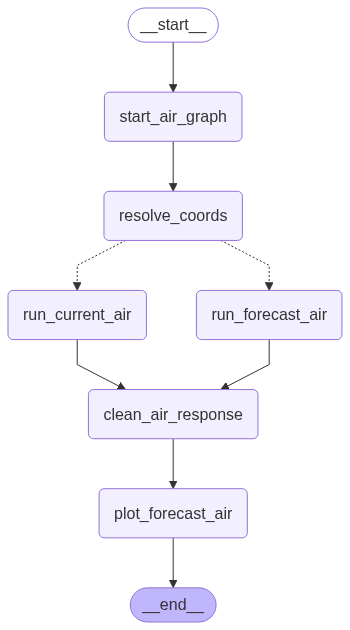

In [7]:
air_graph_wf

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


{'user_prompt': 'What is Air Quality of San Francisco, USA for next weekened',
 'query_type': 'forecast',
 'city_name': 'SAN FRANCISCO',
 'country_code': 'US',
 'days': 7,
 'lat': 37.7790262,
 'lon': -122.419906,
 'raw_data': {'coord': {'lon': -122.4199, 'lat': 37.779},
  'list': [{'main': {'aqi': 1},
    'components': {'co': 81.07,
     'no': 0,
     'no2': 0.61,
     'o3': 59.98,
     'so2': 0.43,
     'pm2_5': 2.05,
     'pm10': 5.69,
     'nh3': 0},
    'dt': 1755496800},
   {'main': {'aqi': 1},
    'components': {'co': 81.01,
     'no': 0,
     'no2': 0.65,
     'o3': 59.29,
     'so2': 0.44,
     'pm2_5': 2.06,
     'pm10': 5.63,
     'nh3': 0},
    'dt': 1755500400},
   {'main': {'aqi': 1},
    'components': {'co': 81.03,
     'no': 0,
     'no2': 0.72,
     'o3': 58.64,
     'so2': 0.47,
     'pm2_5': 2.1,
     'pm10': 5.74,
     'nh3': 0},
    'dt': 1755504000},
   {'main': {'aqi': 1},
    'components': {'co': 81.24,
     'no': 0,
     'no2': 0.8,
     'o3': 58.1,
     'so2': 
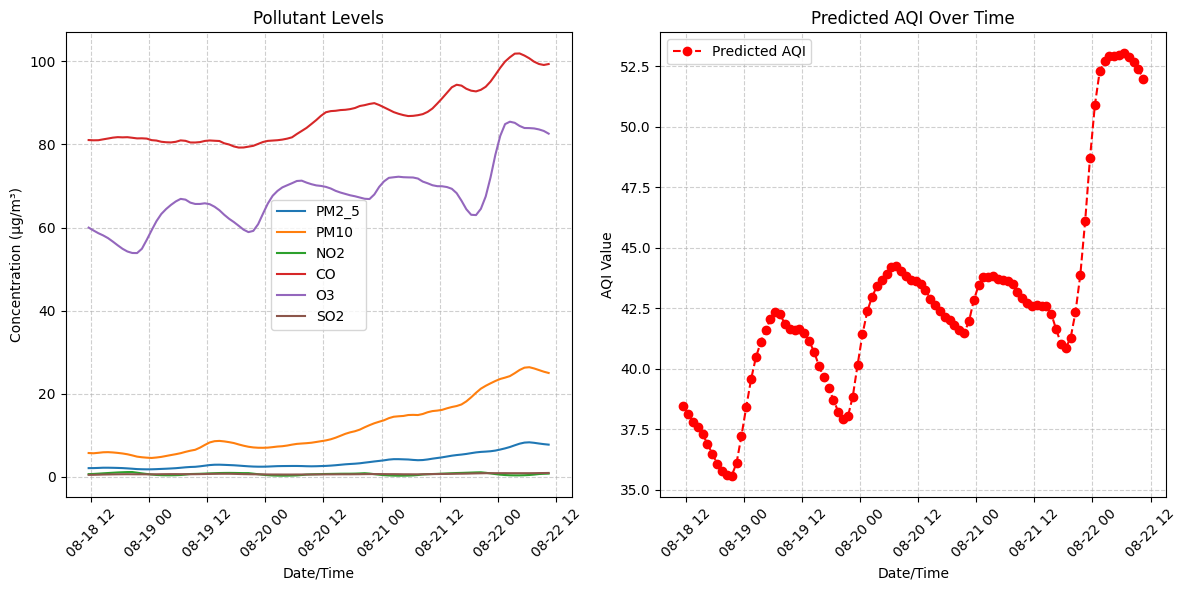

In [8]:
input_prompt = {"user_prompt": "What is Air Quality of San Francisco, USA for next weekened"}
output = air_graph_wf.invoke(input_prompt)
output

In [9]:
import base64
import io
from PIL import Image
import matplotlib.pyplot as plt

def show_base64_image(img_base64: str):
    """Display a base64 image string with matplotlib."""
    # Remove prefix if present ("data:image/png;base64,...")
    if img_base64.startswith("data:image"):
        img_base64 = img_base64.split(",")[1]
    
    # Decode base64 -> bytes
    img_bytes = base64.b64decode(img_base64)
    
    # Load as image
    img = Image.open(io.BytesIO(img_bytes))
    
    # Plot
    plt.figure(figsize=(20, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

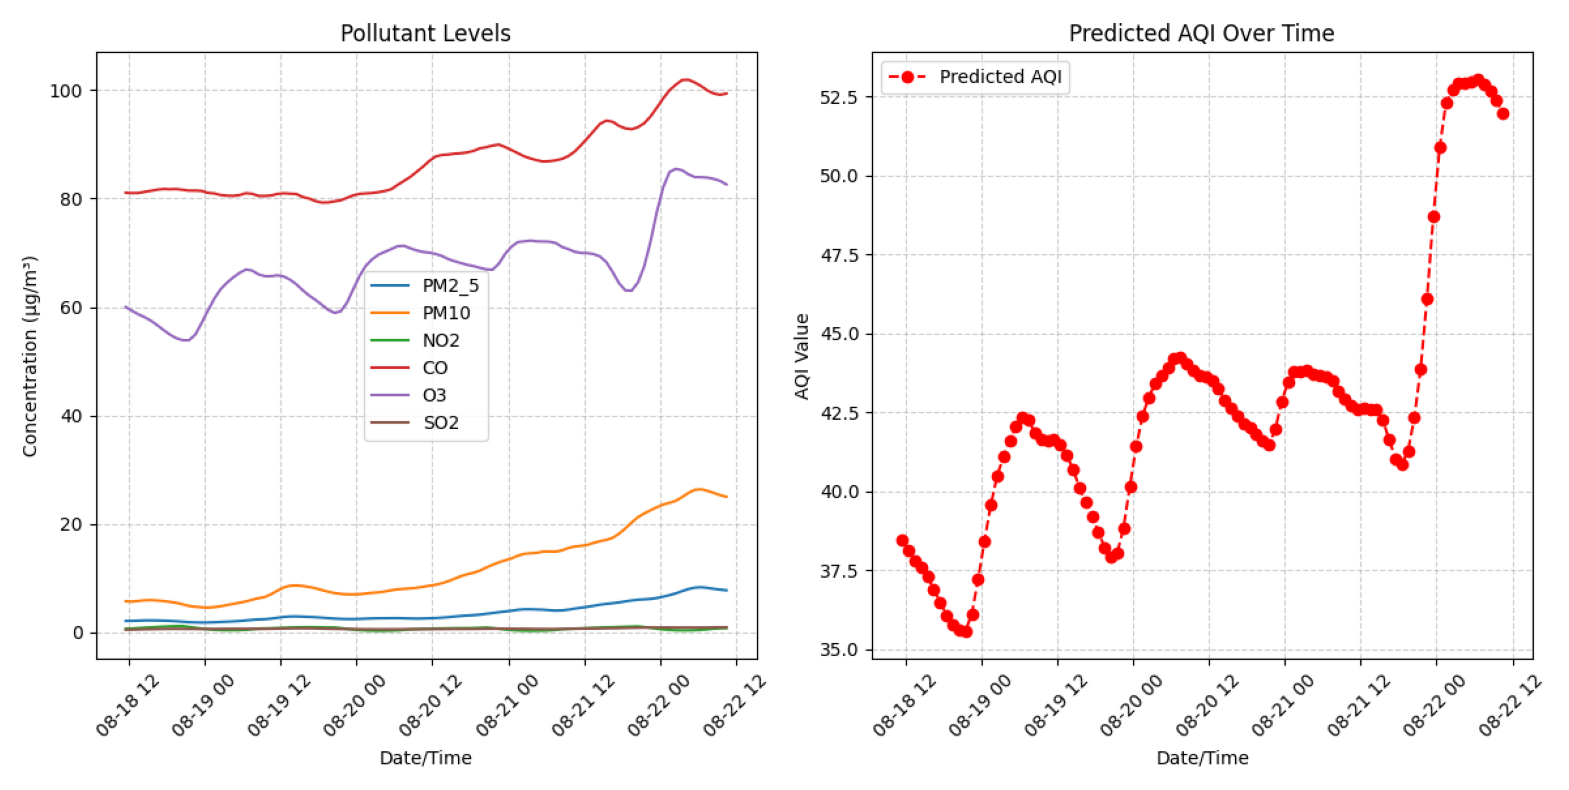

In [11]:
show_base64_image(output['plot'])